In [202]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [203]:
# import database

In [204]:
conn = sqlite3.connect('customer_churn.db')
sql_query = """
       SELECT name
       FROM sqlite_master
       WHERE type='table'
"""

tables = pd.read_sql(sql_query,conn)

# create dataframe

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")
conn.close()
    

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [205]:
# print table names and coulmn names
conn = sqlite3.connect('customer_churn.db')
for tables_name in tables['name']:
    print(f"\nTable Name:{tables_name}")
    columns_query = f"PRAGMA table_info({tables_name});"
    columns = pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())


Table Name:db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [206]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [207]:
# Data cleaning

In [208]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [209]:
#a.drop columns = interest and  pincode
#b.rename columns name to customer name
#c.change data type - dob
#d.fix missing value - country
#e.data standardization - gender


In [210]:
#b.rename columns name to customer name
df_db_customer.rename(columns = {'name':'customer_name'},inplace= True)

In [211]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [212]:
#a.drop columns = interest and  pincode
df_db_customer.drop(df_db_customer.columns[-2:],axis=1,inplace = True)
#df_db_customer.drop(['interests','pincode'])

In [213]:
#c.change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [214]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.8 KB


In [215]:
#data standardization - gender
df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male','Women':'Female'})
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [216]:
#fix missing value - country
df_db_customer[df_db_customer['country'].isna()]                                                                   

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [217]:
state_country_mapping = (
    df_db_customer
    .dropna(subset=['country'])
    .set_index('state')['country']
    .to_dict()
)
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))                      
                      

In [218]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [219]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [220]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [221]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [222]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [223]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [224]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [225]:
df_db_support.drop(df_db_support.columns[-2:],axis=1,inplace = True)

In [226]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [227]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 519.0 bytes


In [228]:
#3 Feature Engineering and Data Analysis

In [229]:
#create a new col using existing col - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [230]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0


In [231]:
#first fix duplicates then merge
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid' , how = 'left')
    .merge(df_db_support, on = 'customerid' , how = 'left'))

In [232]:
df.shape

(23, 20)

In [233]:
df_db_subscription.shape

(21, 12)

In [234]:
df_db_subscription['customerid'].size

21

In [235]:
df_db_subscription['customerid'].nunique()

21

In [236]:
df_db_customer['customerid'].nunique()

21

In [237]:
df_db_support['customerid'].nunique()

7

In [238]:
df_db_support['customerid'].size

9

In [239]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [240]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [241]:
  df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [242]:
#merge
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid' , how = 'left')
    .merge(df_db_support, on = 'customerid' , how = 'left'))

In [243]:
df.shape

(21, 21)

In [244]:
# Data Analysis

In [245]:
#1.churn rate

In [246]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [247]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ",round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [248]:
#2.Retention Rate 
retention_rate = 100 - churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [249]:
# 3. Chrun by plan type 
chrun_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name= 'churn_rate_pct'))

In [250]:
print(chrun_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [251]:
# 4.a Churn by state 
#4.b Chrun by subscription type

In [252]:
churn_by_state = (
    df.groupby('state')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
          Revenue=('monthly_charges', 'sum')
      )
      .round(2)
      .reset_index()
)

In [253]:
churn_by_state

,state,churn_rate_pct,Revenue
0,Delhi,25.00,52.96
1,Karnataka,100.00,20.98
2,Kathmandu,0.00,20.98
3,Maharashtra,0.00,50.97
4,Meghalaya,66.67,42.97
5,Nagaland,0.00,22.99
6,Rajasthan,0.00,36.98
7,Telangana,50.00,30.98
8,Uttar Pradesh,0.00,115.98


In [254]:
churn_by_subscription =  (
    df.groupby('subscription_type')
      .agg(
          churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
          Revenue=('monthly_charges', 'sum')
      )
      .round(2)
      .reset_index()
)

In [255]:
churn_by_subscription

,subscription_type,churn_rate_pct,Revenue
0,Organic,0.00,145.91
1,Paid,16.67,174.94
2,Refferal,83.33,74.94


In [256]:
# 5. ARPU - Avg Revenue per user

In [257]:
arpu = df['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [258]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date 
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ",round(avg_tenure,0 ))

Avg Tenure (Days) =  1551.0


In [259]:
#Revenue loss

In [260]:
Revenue_loss = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue_loss(Rs 'k') = ",Revenue_loss)

Revenue_loss(Rs 'k') =  73.94


In [261]:
#Esclation Rate

In [262]:
escalation_rate = (df['escalations'] == 'Y').mean()*100
print ("Escalation Rate = ",round(escalation_rate,2),"%")

Escalation Rate =  19.05 %


In [263]:
# Avg Complaint per user

In [264]:
Avg_complaint = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg_complaint per user= ",round(Avg_complaint,2))

Avg_complaint per user=  0.43


In [265]:
#10. Correlation Escalation vs Chrun

In [266]:
df['escalations'] = np.where(df['escalations'] == 'Y',1,0)

corr_df = df[['escalations','churn_flag']].dropna()
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation between escalation vs churn is = ",correlation)

Correlation between escalation vs churn is =  0.7669649888473702


In [267]:
# churn risk - create  column using exiting col 
condition = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low','med','high']

df['churn_risk'] = np.select(condition,choices,default= 'unknown')

In [268]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

In [269]:
df[['churn_risk','churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [270]:
# Visualization using Matplotlib

In [271]:
df_visual = df.copy()

In [272]:
df_visual.head(4)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2026.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1411.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2701.0,low


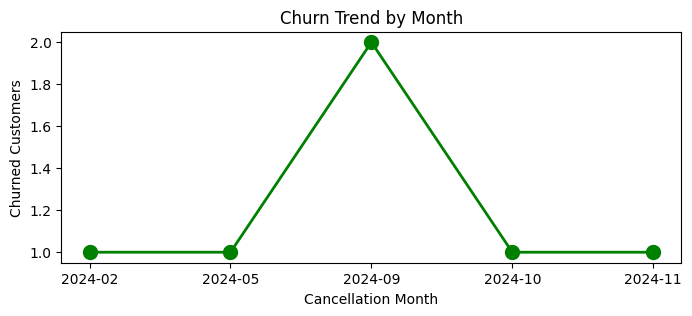

In [273]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1] \
    .groupby('cancellation_month').size()

plt.figure(figsize=(8, 3))

plt.plot(
    churn_trend.index.astype(str),
    churn_trend.values,
    color='green',
    marker='o',
    linestyle='-',
    linewidth=2,
    markersize=10
)

plt.title('Churn Trend by Month')
plt.xlabel('Cancellation Month')
plt.ylabel('Churned Customers')

plt.show()


In [274]:
# 4.2 Churn by plan type

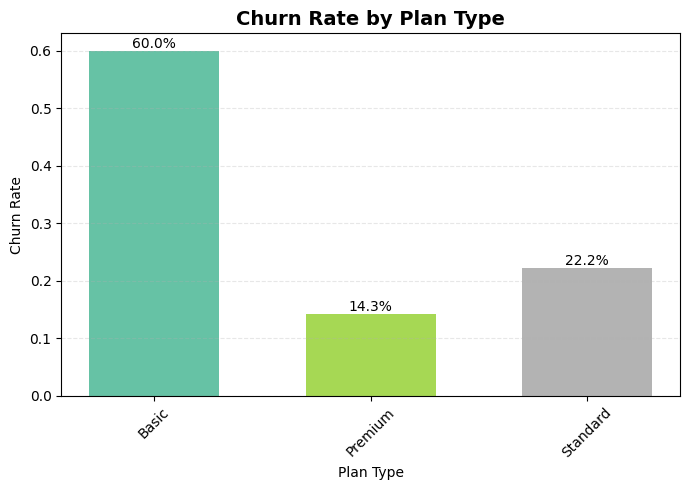

In [275]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_plan.index,
    churn_plan.values,
    width=0.6,
    color=colors
)

plt.title('Churn Rate by Plan Type', fontsize=14, fontweight='bold')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')

# Show percentage on top of each bar
for bar, value in zip(bars, churn_plan.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.1%}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [276]:
# 4.2 Churn by state

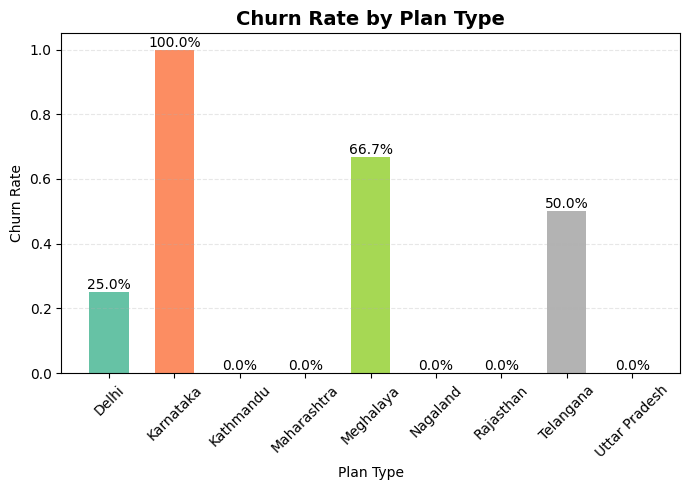

In [277]:
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7, 5))

bars = plt.bar(
    churn_plan.index,
    churn_plan.values,
    width=0.6,
    color=colors
)

plt.title('Churn Rate by Plan Type', fontsize=14, fontweight='bold')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')

# Show percentage on top of each bar
for bar, value in zip(bars, churn_plan.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.1%}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [278]:
# Visulaization using seaborn

In [279]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [288]:
# this is incorrect  as numbers are not assigned based on priority
df_encoded = df_visual[
     ['plan_type','contract_type','churn_score',  'churn_flag','churn_risk','escalations']
]

categorial_cols = ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [290]:
df_encoded.head(4)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0


<Axes: >

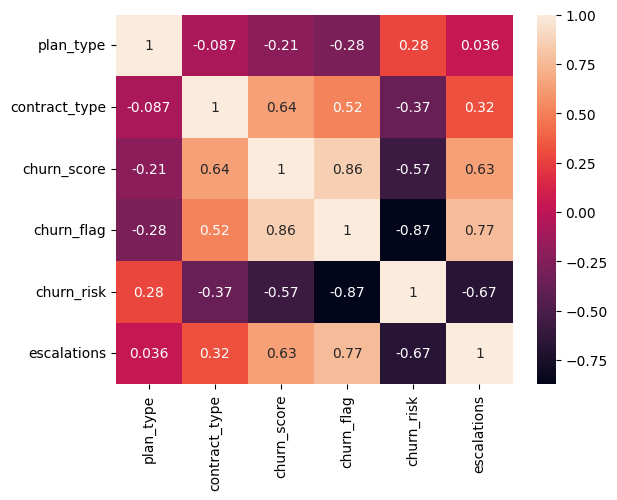

In [291]:
sns.heatmap(df_encoded.corr(),annot=True)

In [309]:
import warnings
warnings.filterwarnings('ignore')

df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score',
     'churn_flag', 'churn_risk', 'escalations']
].copy()

order_mapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low', 'medium', 'high']
}

for col, order in order_mapping.items():
    df_encoded[col] = pd.Categorical(
        df_encoded[col],
        categories=order,
        ordered=True
    ).codes

In [310]:
df_encoded.head(4)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0


<Axes: >

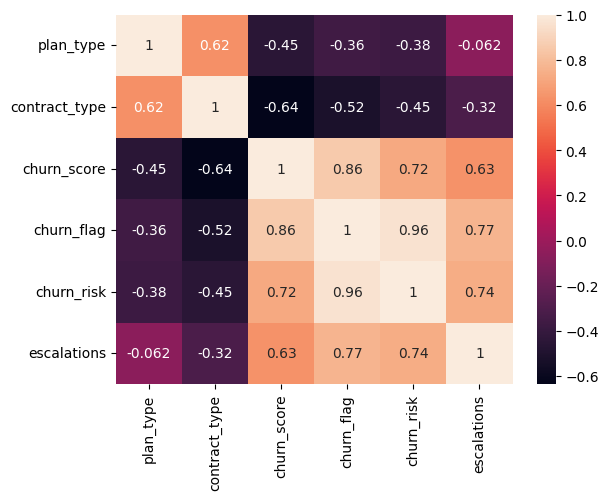

In [311]:
sns.heatmap(df_encoded.corr(),annot=True)

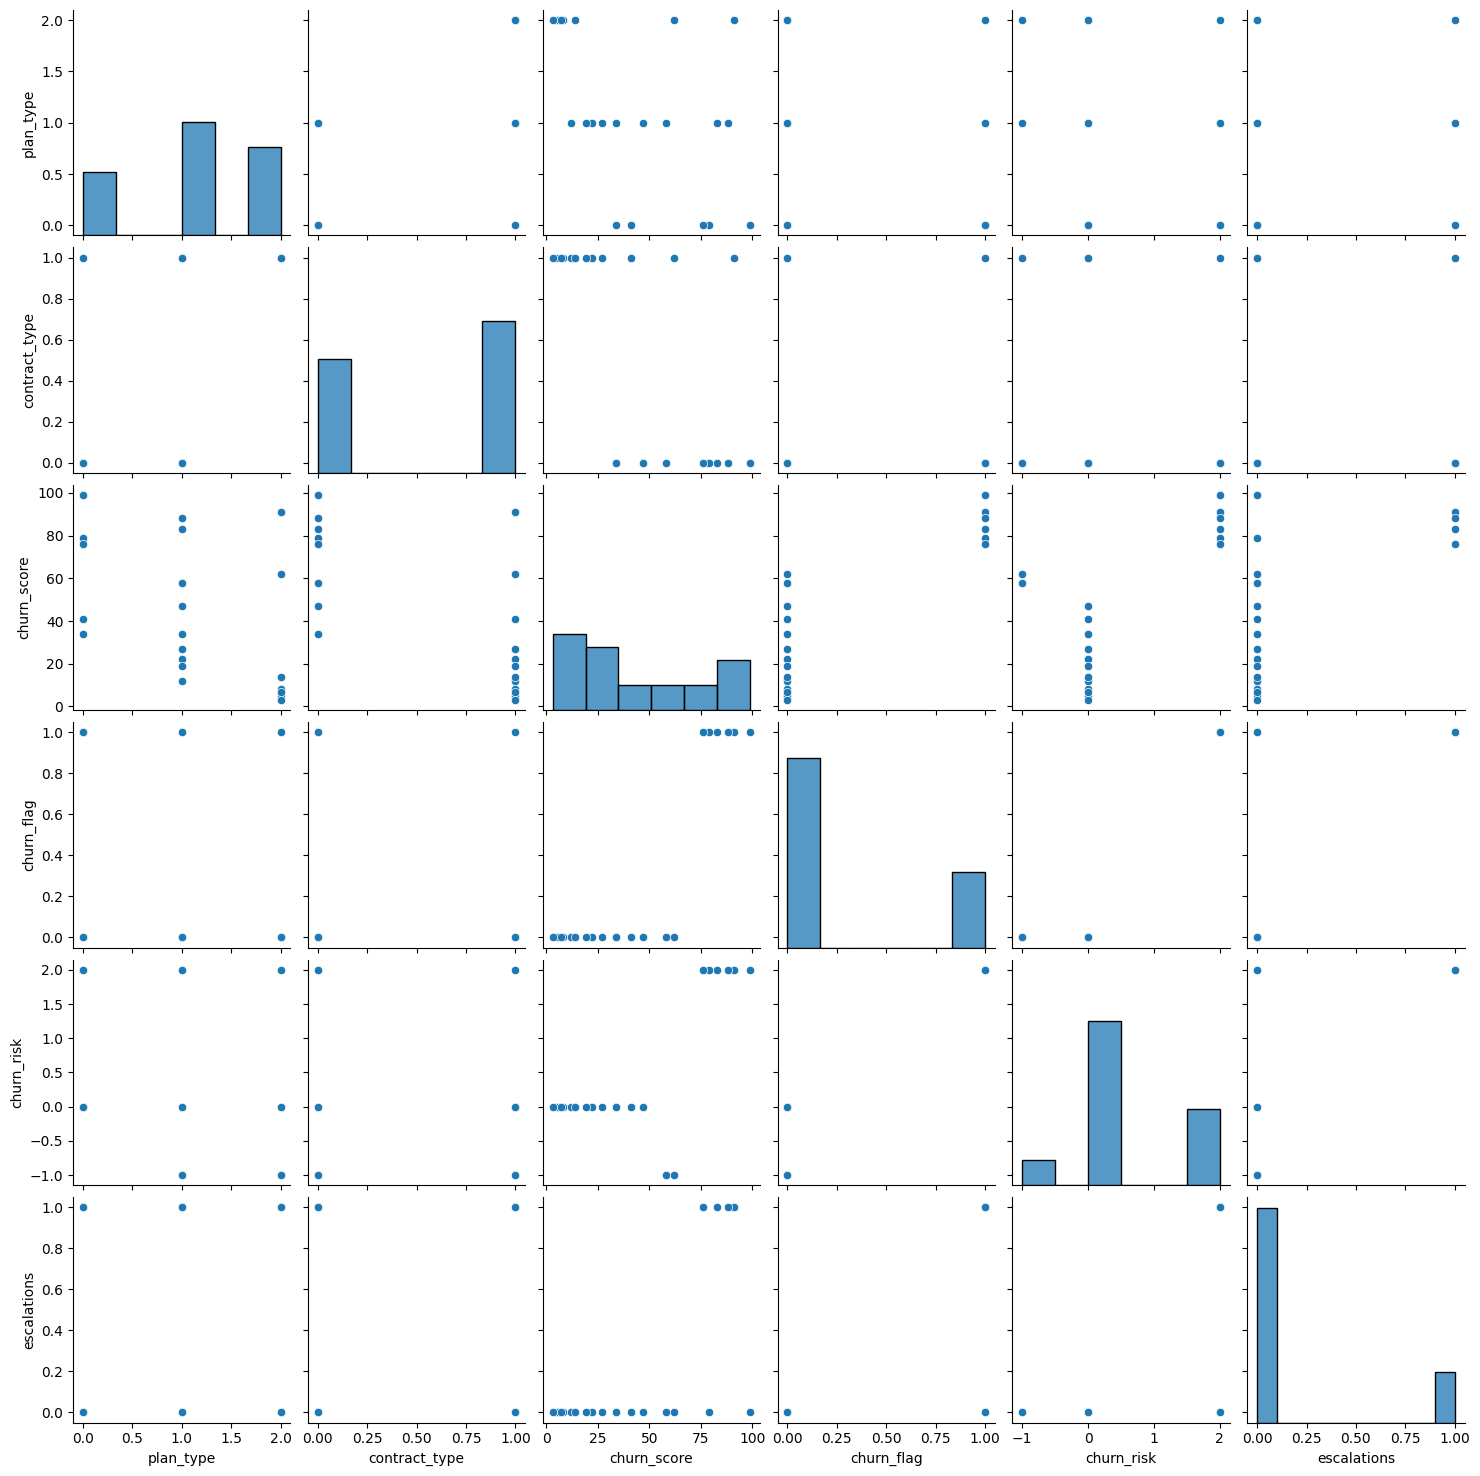

In [312]:
#pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [313]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

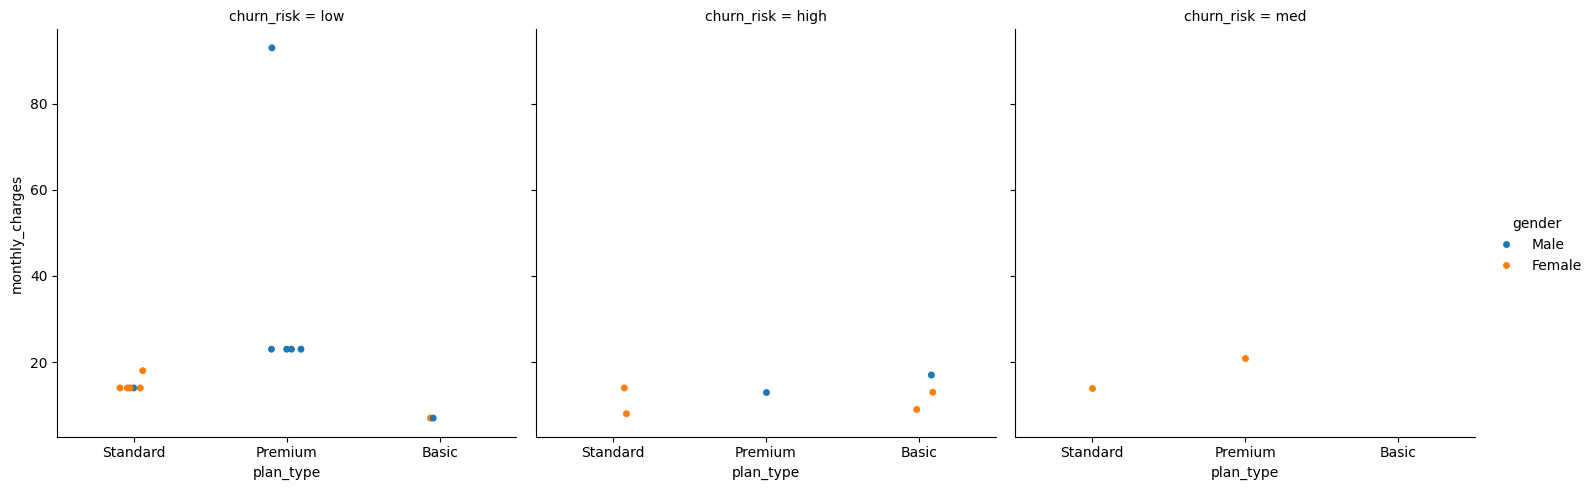

In [315]:
#catplt/Facegrid plot
sns.catplot(data= df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col='churn_risk')

In [316]:
#pivot table

In [319]:
pivot = pd.pivot_table(
    df_encoded,
    values='churn_flag',
    index='plan_type',
    aggfunc='count',
    fill_value=0
)

print(pivot)

           churn_flag
plan_type            
0                   5
1                   9
2                   7


In [320]:
pivot = pd.pivot_table(
    df_encoded,
    values='churn_score',
    index='plan_type',
    aggfunc='mean'
)

print(pivot)

           churn_score
plan_type             
0            65.800000
1            43.333333
2            27.142857


In [323]:
pivot = pd.pivot_table(
    df_encoded,
    values='churn_score',
    index='plan_type',
    columns='churn_risk',
    aggfunc='mean'
).reset_index()

print(pivot)pivot = pd.pivot_table(
    df_encoded,
    values=['churn_flag', 'monthly_charges', 'customerid'],
    index='plan_type',
    aggfunc={
        'churn_flag': 'sum',
        'monthly_charges': 'mean',
        'customerid': 'count'
    },
    fill_value=0
)

print(pivot)

churn_risk  plan_type    -1          0          2
0                   0   NaN  37.500000  84.666667
1                   1  58.0  26.833333  85.500000
2                   2  62.0   7.400000  91.000000


In [327]:
pivot = pd.pivot_table(
    df_visual,
    values=['churn_flag', 'monthly_charges', 'customerid'],
    index='plan_type',
    aggfunc={
        'churn_flag': 'mean',
        'monthly_charges': 'sum',
        'customerid': 'count'
    },
    fill_value=0
).reset_index()

print(pivot)

  plan_type  churn_flag  customerid  monthly_charges
0     Basic    0.600000           5            52.95
1   Premium    0.142857           7           218.93
2  Standard    0.222222           9           123.91
